In [1]:
from pathlib import Path

def find_project_root(start_path: Path) -> Path:
    """
    Find project root folder by checking for requirements.txt and data folder.
    """
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DATA_PATH = PROCESSED_DIR / "train_data.csv"
TEST_DATA_PATH = PROCESSED_DIR / "test_data.csv"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Train data path:", TRAIN_DATA_PATH)
print("Test data path:", TEST_DATA_PATH)
print("Models folder:", MODELS_DIR)
print("Figures folder:", FIGURES_DIR)
print("Metrics folder:", METRICS_DIR)

Project root: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05
Train data path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/data/processed/train_data.csv
Test data path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/data/processed/test_data.csv
Models folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models
Figures folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures
Metrics folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics


Load train and test datasets

In [2]:
import pandas as pd

if not TRAIN_DATA_PATH.exists():
    raise FileNotFoundError(
        f"train_data.csv not found at: {TRAIN_DATA_PATH}\n"
        "Please run 04_train_test_split.ipynb first."
    )

if not TEST_DATA_PATH.exists():
    raise FileNotFoundError(
        f"test_data.csv not found at: {TEST_DATA_PATH}\n"
        "Please run 04_train_test_split.ipynb first."
    )

train_data = pd.read_csv(TRAIN_DATA_PATH)
test_data = pd.read_csv(TEST_DATA_PATH)

print("Train and test datasets loaded successfully.")
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain columns:")
print(train_data.columns.tolist())

print("\nTest columns:")
print(test_data.columns.tolist())

display(train_data.head())
display(test_data.head())

Train and test datasets loaded successfully.
Train shape: (31278, 2)
Test shape: (7820, 2)

Train columns:
['clean_text', 'label']

Test columns:
['clean_text', 'label']


,clean_text,label
0,catalan government appeal direct rule constitu...,1
1,sick lie cnn luck today turn cnn day meme spre...,0
2,cop ask mayor remove black life matter banner ...,0
3,racist barber pull gun black man asked haircut...,0
4,lol democrat congressman say best way fight fa...,0


,clean_text,label
0,sept law weakens international relation saudi ...,1
1,breaking trump top insane weekend announcing n...,0
2,ugandan mp get work extending president rule s...,1
3,trump belief obama born united state campaign ...,1
4,colbert rundown harriet tubman news gonna piss...,0


Prepare input and target values

In [3]:
required_columns = ["clean_text", "label"]

for column in required_columns:
    if column not in train_data.columns:
        raise ValueError(f"Required column missing in train_data: {column}")

    if column not in test_data.columns:
        raise ValueError(f"Required column missing in test_data: {column}")


train_data = train_data.copy()
test_data = test_data.copy()

train_data["clean_text"] = train_data["clean_text"].fillna("").astype(str)
test_data["clean_text"] = test_data["clean_text"].fillna("").astype(str)

train_data["label"] = train_data["label"].astype(int)
test_data["label"] = test_data["label"].astype(int)

train_data = train_data[train_data["clean_text"].str.strip() != ""]
test_data = test_data[test_data["clean_text"].str.strip() != ""]

X_train = train_data["clean_text"]
y_train = train_data["label"]

X_test = test_data["clean_text"]
y_test = test_data["label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train shape: (31278,)
y_train shape: (31278,)
X_test shape: (7820,)
y_test shape: (7820,)

Training class distribution:
label
1    16957
0    14321
Name: count, dtype: int64

Testing class distribution:
label
1    4239
0    3581
Name: count, dtype: int64


Tokenization and padding

In [4]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 300
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Tokenization and padding completed.")
print("X_train_padded shape:", X_train_padded.shape)
print("X_test_padded shape:", X_test_padded.shape)

print("\nVocabulary size:", len(tokenizer.word_index))

I0000 00:00:1786879226.397788    7040 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786879226.422250    7040 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786879234.225467    7040 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786879253.853037    7040 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Tokenization and padding completed.
X_train_padded shape: (31278, 300)
X_test_padded shape: (7820, 300)

Vocabulary size: 91709


Convert labels to arrays

In [6]:
import numpy as np

y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

print("y_train_array shape:", y_train_array.shape)
print("y_test_array shape:", y_test_array.shape)

y_train_array shape: (31278,)
y_test_array shape: (7820,)


Build LSTM model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    LSTM(128),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lstm_model.summary()

E0000 00:00:1786879290.110428    7040 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

Train LSTM model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_padded,
    y_train_array,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM model training completed.")

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 201s 499ms/step - accuracy: 0.5406 - loss: 0.6842 - val_accuracy: 0.5379 - val_loss: 0.6903
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 212s 541ms/step - accuracy: 0.5410 - loss: 0.6906 - val_accuracy: 0.5379 - val_loss: 0.6897
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 215s 549ms/step - accuracy: 0.5416 - loss: 0.6875 - val_accuracy: 0.5379 - val_loss: 0.6857
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 195s 498ms/step - accuracy: 0.8154 - loss: 0.4144 - val_accuracy: 0.9254 - val_loss: 0.2637
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 210s 536ms/step - accuracy: 0.8480 - loss: 0.3961 - val_accuracy: 0.8286 - val_loss: 0.3352
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 175s 448ms/step - accuracy: 0.9260 - loss: 0.2193 - val_accuracy: 0.9693 - val_loss: 0.1252
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 205s 526ms/step - accuracy: 0.9473 - loss: 0.1569 - val_accuracy: 0.9647 - val_loss: 0.1596
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 298s 617ms/step - accuracy: 0.9497 -

Plot training accuracy

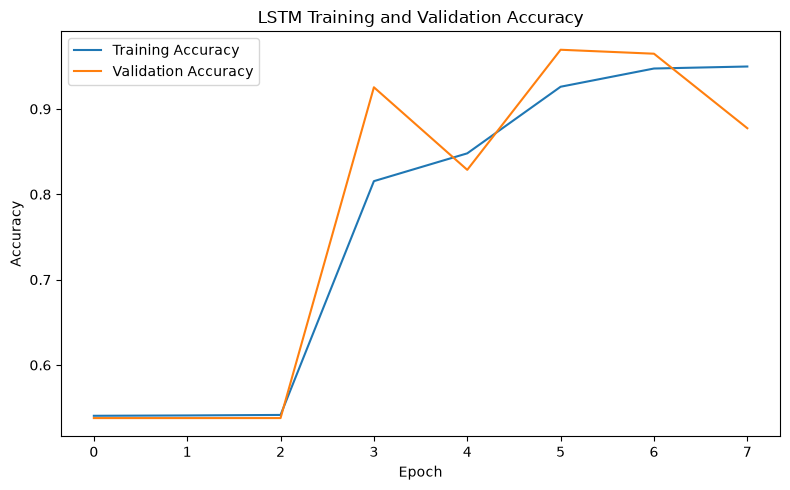

LSTM accuracy graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lstm_accuracy.png


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

accuracy_plot_path = FIGURES_DIR / "lstm_accuracy.png"
plt.savefig(accuracy_plot_path)
plt.show()

print("LSTM accuracy graph saved to:", accuracy_plot_path)

Plot training loss

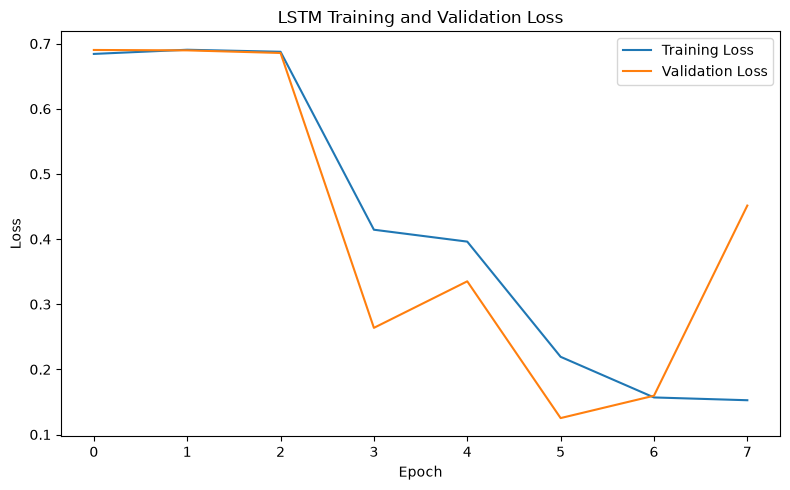

LSTM loss graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lstm_loss.png


In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

loss_plot_path = FIGURES_DIR / "lstm_loss.png"
plt.savefig(loss_plot_path)
plt.show()

print("LSTM loss graph saved to:", loss_plot_path)

Make predictions

In [11]:
y_pred_prob = lstm_model.predict(X_test_padded).ravel()

y_pred = (y_pred_prob >= 0.5).astype(int)

print("Predictions completed.")
print("y_pred shape:", y_pred.shape)
print("y_pred_prob shape:", y_pred_prob.shape)

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test_array[:10])

245/245 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step
Predictions completed.
y_pred shape: (7820,)
y_pred_prob shape: (7820,)

First 10 predicted labels:
[1 0 1 1 0 1 1 0 1 1]

First 10 actual labels:
[1 0 1 1 0 1 1 0 1 1]


Evaluation metrics

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test_array, y_pred)

weighted_precision = precision_score(
    y_test_array,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test_array,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test_array,
    y_pred,
    average="weighted",
    zero_division=0
)

# Fake News = 0
fake_precision = precision_score(y_test_array, y_pred, pos_label=0, zero_division=0)
fake_recall = recall_score(y_test_array, y_pred, pos_label=0, zero_division=0)
fake_f1 = f1_score(y_test_array, y_pred, pos_label=0, zero_division=0)

# Real News = 1
real_precision = precision_score(y_test_array, y_pred, pos_label=1, zero_division=0)
real_recall = recall_score(y_test_array, y_pred, pos_label=1, zero_division=0)
real_f1 = f1_score(y_test_array, y_pred, pos_label=1, zero_division=0)

roc_auc = roc_auc_score(y_test_array, y_pred_prob)

print("LSTM Evaluation Results")
print("-----------------------")
print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(weighted_precision, 4))
print("Weighted Recall:", round(weighted_recall, 4))
print("Weighted F1-score:", round(weighted_f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nFake News Class Metrics")
print("Precision:", round(fake_precision, 4))
print("Recall:", round(fake_recall, 4))
print("F1-score:", round(fake_f1, 4))

print("\nReal News Class Metrics")
print("Precision:", round(real_precision, 4))
print("Recall:", round(real_recall, 4))
print("F1-score:", round(real_f1, 4))

LSTM Evaluation Results
-----------------------
Accuracy: 0.9728
Weighted Precision: 0.9733
Weighted Recall: 0.9728
Weighted F1-score: 0.9727
ROC-AUC: 0.989

Fake News Class Metrics
Precision: 0.9893
Recall: 0.9509
F1-score: 0.9697

Real News Class Metrics
Precision: 0.9598
Recall: 0.9913
F1-score: 0.9753


Classification report

In [13]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_array,
    y_pred,
    target_names=["Fake News", "Real News"],
    zero_division=0
)

print("Classification Report")
print("---------------------")
print(report)

Classification Report
---------------------
              precision    recall  f1-score   support

   Fake News       0.99      0.95      0.97      3581
   Real News       0.96      0.99      0.98      4239

    accuracy                           0.97      7820
   macro avg       0.97      0.97      0.97      7820
weighted avg       0.97      0.97      0.97      7820



Save metrics CSV

In [14]:
metrics_data = {
    "model": ["LSTM"],
    "accuracy": [accuracy],
    "precision": [weighted_precision],
    "recall": [weighted_recall],
    "f1_score": [weighted_f1],
    "roc_auc": [roc_auc],
    "fake_precision": [fake_precision],
    "fake_recall": [fake_recall],
    "fake_f1": [fake_f1],
    "real_precision": [real_precision],
    "real_recall": [real_recall],
    "real_f1": [real_f1]
}

metrics_df = pd.DataFrame(metrics_data)

metrics_output_path = METRICS_DIR / "lstm_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)

display(metrics_df)

print("LSTM metrics saved to:", metrics_output_path)

,model,accuracy,precision,recall,f1_score,roc_auc,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,LSTM,0.972762,0.973286,0.972762,0.972712,0.98905,0.98925,0.950852,0.969671,0.959799,0.991272,0.975281


LSTM metrics saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/lstm_metrics.csv


ROC curve

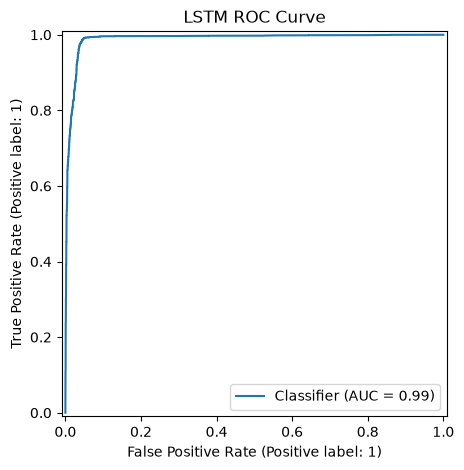

LSTM ROC curve saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/lstm_roc_curve.png


In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test_array,
    y_pred_prob
)

plt.title("LSTM ROC Curve")
plt.tight_layout()

roc_curve_path = FIGURES_DIR / "lstm_roc_curve.png"
plt.savefig(roc_curve_path)
plt.show()

print("LSTM ROC curve saved to:", roc_curve_path)

Save tokenizer

In [16]:
import json

tokenizer_output_path = MODELS_DIR / "lstm_tokenizer.json"

tokenizer_json = tokenizer.to_json()

with open(tokenizer_output_path, "w", encoding="utf-8") as file:
    file.write(tokenizer_json)

print("LSTM tokenizer saved to:", tokenizer_output_path)

LSTM tokenizer saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models/lstm_tokenizer.json


Verify saved model and tokenizer

In [17]:
from pathlib import Path
import json

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_output_path = MODELS_DIR / "lstm_model.keras"
tokenizer_output_path = MODELS_DIR / "lstm_tokenizer.json"

# Save LSTM model
lstm_model.save(model_output_path)

# Save tokenizer
with open(tokenizer_output_path, "w", encoding="utf-8") as file:
    file.write(tokenizer.to_json())

print("LSTM model saved to:", model_output_path)
print("Tokenizer saved to:", tokenizer_output_path)

LSTM model saved to: ../models/lstm_model.keras
Tokenizer saved to: ../models/lstm_tokenizer.json


In [18]:
from pathlib import Path
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# Project directories
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Saved model and tokenizer paths
model_output_path = MODELS_DIR / "lstm_model.keras"
tokenizer_output_path = MODELS_DIR / "lstm_tokenizer.json"

# Check files
print("Model path:", model_output_path)
print("Tokenizer path:", tokenizer_output_path)

print("\nModel exists:", model_output_path.exists())
print("Tokenizer exists:", tokenizer_output_path.exists())

# Load saved LSTM model
loaded_lstm_model = load_model(model_output_path)

# Load saved tokenizer
with open(tokenizer_output_path, "r", encoding="utf-8") as file:
    loaded_tokenizer_json = file.read()

loaded_tokenizer = tokenizer_from_json(
    loaded_tokenizer_json
)

print("\nSaved LSTM model loaded successfully.")
print("Saved tokenizer loaded successfully.")

Model path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models/lstm_model.keras
Tokenizer path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/models/lstm_tokenizer.json

Model exists: True
Tokenizer exists: True

Saved LSTM model loaded successfully.
Saved tokenizer loaded successfully.


Prediction function for cleaned text

In [19]:
def predict_cleaned_news_lstm(cleaned_news_text):
    """
    Predict Fake/Real news using cleaned English text.
    """

    sequence = tokenizer.texts_to_sequences([cleaned_news_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    real_probability = lstm_model.predict(padded_sequence)[0][0]
    fake_probability = 1 - real_probability

    if real_probability >= 0.5:
        result = "Real News"
        confidence = real_probability
    else:
        result = "Fake News"
        confidence = fake_probability

    return {
        "prediction": result,
        "confidence": confidence,
        "fake_probability": fake_probability,
        "real_probability": real_probability
    }


test_text = X_test.iloc[1]
output = predict_cleaned_news_lstm(test_text)

print("Prediction:", output["prediction"])
print("Confidence:", round(output["confidence"] * 100, 2), "%")
print("Fake Probability:", round(output["fake_probability"] * 100, 2), "%")
print("Real Probability:", round(output["real_probability"] * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
Prediction: Fake News
Confidence: 98.81 %
Fake Probability: 98.81 %
Real Probability: 1.19 %
